In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#importing libraries

In [2]:
train_df = pd.read_csv("crime_train.csv")
test_df = pd.read_csv("crime_test.csv")
#Loading data

In [3]:
train_df.head()
train_df.info()
#inspecting and understanding data for preprocessing

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22489 entries, 0 to 22488
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         22489 non-null  int64  
 1   Num                22489 non-null  int64  
 2   case_filed         22489 non-null  object 
 3   city               22489 non-null  object 
 4   area               22489 non-null  int64  
 5   crime_description  22489 non-null  object 
 6   age                22489 non-null  float64
 7   sex                22489 non-null  object 
 8   weapon             19217 non-null  object 
 9   domain             22489 non-null  object 
 10  police_department  22489 non-null  float64
 11  closed             22489 non-null  object 
dtypes: float64(2), int64(3), object(7)
memory usage: 2.1+ MB


In [4]:
train_df = train_df.drop(columns=['Unnamed: 0', 'Num'])
test_df  = test_df.drop(columns=['Unnamed: 0', 'Num'])
#Index and identifier columns were removed as they do not carry predictive information.

In [5]:
train_df.head()
train_df.info()
#rechecking if the columns have been dropped or not

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22489 entries, 0 to 22488
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   case_filed         22489 non-null  object 
 1   city               22489 non-null  object 
 2   area               22489 non-null  int64  
 3   crime_description  22489 non-null  object 
 4   age                22489 non-null  float64
 5   sex                22489 non-null  object 
 6   weapon             19217 non-null  object 
 7   domain             22489 non-null  object 
 8   police_department  22489 non-null  float64
 9   closed             22489 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 1.7+ MB


In [6]:
train_df['closed'].value_counts()
#target column closed

closed
Yes    11253
No     11236
Name: count, dtype: int64

In [7]:
train_df['closed'] = train_df['closed'].map({'Yes': 1, 'No': 0})
test_df['closed'] = test_df['closed'].map({'Yes': 1, 'No': 0})
#Convert target column to 0/1

In [8]:
train_df['closed'].unique()
test_df['closed'].unique()
#Verifying if it only has 0/1

array([1, 0])

In [9]:
train_df['weapon'] = train_df['weapon'].fillna('Unknown')
test_df['weapon']  = test_df['weapon'].fillna('Unknown')
#replacing the weapon column with Unknown

In [10]:
# convert to datetime
train_df['case_filed'] = pd.to_datetime(train_df['case_filed'], errors='coerce')
test_df['case_filed']  = pd.to_datetime(test_df['case_filed'], errors='coerce')


In [11]:
# extracting useful features
for df in [train_df, test_df]:
    df['year']  = df['case_filed'].dt.year
    df['month'] = df['case_filed'].dt.month
    df['hour']  = df['case_filed'].dt.hour

In [12]:
# drop original column
train_df = train_df.drop(columns=['case_filed'])
test_df  = test_df.drop(columns=['case_filed'])

In [13]:
#hot encode 3 columns:sex,weapon,domain
train_df = pd.get_dummies(
    train_df,
    columns=['sex', 'weapon', 'domain'],
    drop_first=True
)

test_df = pd.get_dummies(
    test_df,
    columns=['sex', 'weapon', 'domain'],
    drop_first=True
)


In [14]:
#frequency coding city and crime description as they have high cardinality
city_freq = train_df['city'].value_counts(normalize=True)

train_df['city_freq'] = train_df['city'].map(city_freq)
test_df['city_freq']  = test_df['city'].map(city_freq)

train_df['city_freq'] = train_df['city_freq'].fillna(0)
test_df['city_freq']  = test_df['city_freq'].fillna(0)

train_df = train_df.drop(columns=['city'])
test_df  = test_df.drop(columns=['city'])

crime_freq = train_df['crime_description'].value_counts(normalize=True)

train_df['crime_freq'] = train_df['crime_description'].map(crime_freq)
test_df['crime_freq']  = test_df['crime_description'].map(crime_freq)

train_df['crime_freq'] = train_df['crime_freq'].fillna(0)
test_df['crime_freq']  = test_df['crime_freq'].fillna(0)

train_df = train_df.drop(columns=['crime_description'])
test_df  = test_df.drop(columns=['crime_description'])



In [15]:
print(train_df.isnull().sum())
print(test_df.isnull().sum())
#NaN checking

area                       0
age                        0
police_department          0
closed                     0
year                       0
month                      0
hour                       0
sex_M                      0
sex_X                      0
weapon_Explosives          0
weapon_Firearm             0
weapon_Knife               0
weapon_Other               0
weapon_Poison              0
weapon_Unknown             0
domain_Other Crime         0
domain_Traffic Fatality    0
domain_Violent Crime       0
city_freq                  0
crime_freq                 0
dtype: int64
area                       0
age                        0
police_department          0
closed                     0
year                       0
month                      0
hour                       0
sex_M                      0
sex_X                      0
weapon_Explosives          0
weapon_Firearm             0
weapon_Knife               0
weapon_Other               0
weapon_Poison              0
w

In [16]:
# separating features and target
X = train_df.drop(columns=['closed']).values
y = train_df['closed'].values

# shuffle (from scratch)
np.random.seed(42)
m = X.shape[0]
indices = np.random.permutation(m)
X = X[indices]
y = y[indices]

# train-validation split
split = int(0.8 * m)

X_train = X[:split]
y_train = y[:split]

X_val = X[split:]
y_val = y[split:]

# test features only
X_test = test_df.drop(columns=['closed']).values


In [29]:
# converting into float
X_train = X_train.astype(float)
X_val   = X_val.astype(float)
X_test  = X_test.astype(float)

y_train = y_train.astype(float)
y_val   = y_val.astype(float)


In [18]:
#feature scaling
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0) + 1e-8

X_train = (X_train - mean) / std
X_val   = (X_val   - mean) / std
X_test  = (X_test  - mean) / std


In [19]:
print("X_train NaN:", np.isnan(X_train).any())
print("X_train inf:", np.isinf(X_train).any())

print("y_train NaN:", np.isnan(y_train).any())
print("y_train unique:", np.unique(y_train))


X_train NaN: False
X_train inf: False
y_train NaN: False
y_train unique: [0. 1.]


In [22]:
def sigmoid(z):
    z = np.clip(z, -500, 500)   # prevent overflow
    return 1 / (1 + np.exp(-z))


In [23]:
#computes probabilities :z=Xw+b, y^=σ(z)
def forward(X, w, b):
    z = X @ w + b
    y_hat = sigmoid(z)
    return y_hat


In [24]:
#logistic loss function L=−m1​∑[ylog(y^​)+(1−y)log(1−y^​)] 
def compute_loss(y, y_hat):
    eps = 1e-15  # numerical stability
    y_hat = np.clip(y_hat, eps, 1 - eps)
    loss = -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))
    return loss


In [25]:
#computes gradient parameters
def compute_gradients(X, y, y_hat):
    m = X.shape[0]
    dw = (1 / m) * (X.T @ (y_hat - y))
    db = (1 / m) * np.sum(y_hat - y)
    return dw, db

In [26]:
def train_logistic_regression(X, y, lr=0.01, epochs=1000):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0

    losses = []

    for epoch in range(epochs):
        # forward pass
        y_hat = forward(X, w, b)

        # loss
        loss = compute_loss(y, y_hat)
        losses.append(loss)

        # gradients
        dw, db = compute_gradients(X, y, y_hat)

        # update parameters
        w -= lr * dw
        b -= lr * db

        if epoch % 100 == 0:
            print(f"Epoch {epoch}: Loss = {loss:.4f}")

    return w, b, losses


In [27]:
def predict(X, w, b, threshold=0.5):
    probs = sigmoid(X @ w + b)
    return (probs >= threshold).astype(int)


Epoch 0: Loss = 0.6931
Epoch 100: Loss = 0.6930
Epoch 200: Loss = 0.6929
Epoch 300: Loss = 0.6928
Epoch 400: Loss = 0.6928
Epoch 500: Loss = 0.6928
Epoch 600: Loss = 0.6928
Epoch 700: Loss = 0.6928
Epoch 800: Loss = 0.6927
Epoch 900: Loss = 0.6927


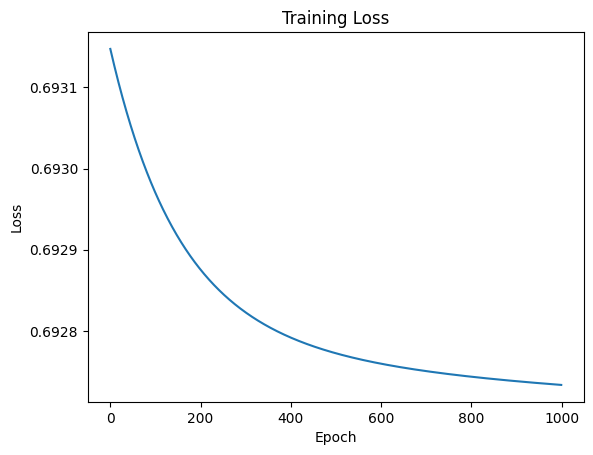

Final Training Accuracy: 0.5124784614529487


In [30]:
# Train
w, b, losses = train_logistic_regression(
    X_train,
    y_train,
    lr=0.01,
    epochs=1000
)

# Plot loss
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

y_train_pred = predict(X_train, w, b)
train_acc = np.mean(y_train_pred == y_train)

print("Final Training Accuracy:", train_acc)
